In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Lab-1
## IG1

In [12]:
lena = cv2.imread('./test_assets/Lena.jpg', 0)
box=cv2.imread('./test_assets/box.jpg', 0)

In [13]:
kernel1 = np.array([
    [1,  4,  6,  4, 1],
    [4, 16, 24, 16, 4],
    [6, 24, 36, 24, 6],
    [4, 16, 24, 16, 4],
    [1,  4,  6,  4, 1]
], dtype=np.float32)

kernel2 = np.array([[-1, 0, 1],
                    [-1, 0, 1],
                    [-1, 0, 1]], dtype=np.float32)

In [ ]:
# img_conv = cv2.filter2D(image, ddepth=cv2.CV_32F, kernel= kernel1)

def convolution2D(image, kernel):
    kernel=np.flip(kernel)
    ih,iw=image.shape
    kh,kw=kernel.shape
    border=kh//2
    bordered_image=cv2.copyMakeBorder(image,border,border,border,border,cv2.BORDER_CONSTANT,value=0)
    result = np.zeros((ih, iw), dtype=np.float32)
    for j in range(ih):
        for i in range(iw):
            region=bordered_image[j:j+kh,i:i+kw]
            mul=np.multiply(region,kernel)
            result[j,i]=np.sum(mul)
    return result

In [15]:
lena_conv1 = convolution2D(lena, kernel1)
lena_normalized1 = np.round(cv2.normalize(lena_conv1, None, 0, 255, cv2.NORM_MINMAX)).astype(np.uint8)

Text(0.5, 1.0, 'Convolution')

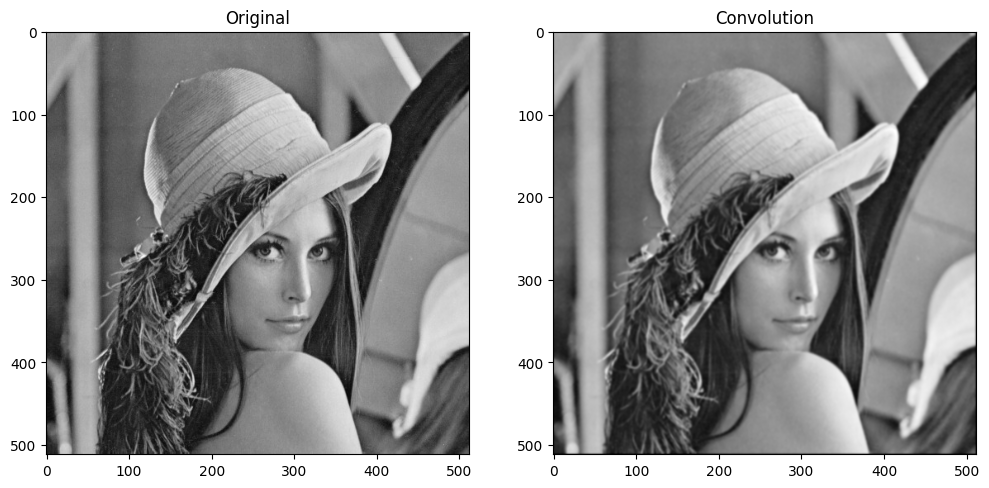

In [16]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(lena, cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(lena_normalized1, cmap="gray")
plt.title("Convolution")